<a href="https://colab.research.google.com/github/alevianweb/UAS_Bengkod/blob/main/UAS_BengkelKoding_Alevian.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UAS Bengkel Koding Data Science

**Nama :** Firstanto Alevian Nugroho  
**NIM  :** A11.2023.15382  
**Dataset :** Sales and Marketing Customer Dataset  

---

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import warnings
import joblib

from sklearn.model_selection  import train_test_split, RandomizedSearchCV
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, VotingClassifier
from sklearn.svm              import SVC
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.preprocessing    import StandardScaler, OrdinalEncoder
from sklearn.metrics          import (accuracy_score, precision_score,
                                       recall_score, f1_score,
                                       confusion_matrix, classification_report)
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')
print("Library berhasil diimport.")


Library berhasil diimport.


## 2. Load Dataset

In [2]:
df = pd.read_csv('Sales - Marketing customer dataset.csv')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')


Jumlah baris  : 15,000
Jumlah kolom  : 30


## 3. Exploratory Data Analysis (EDA)

EDA adalah langkah pertama yang **wajib** dilakukan sebelum membangun model.  
Tujuannya adalah memahami struktur data, menemukan anomali, dan melihat pola awal
yang nantinya akan memandu proses preprocessing dan pemilihan fitur.

### 3.1 Tampilkan 5 Baris Pertama, Info Dataset, dan Statistik Deskriptif

Langkah ini memberi gambaran awal tentang:
- Nama dan tipe tiap kolom
- Contoh nilai yang ada di dataset
- Ringkasan statistik (mean, std, min, max, dsb.)

In [3]:
print("=== 5 BARIS PERTAMA ===")
display(df.head())


=== 5 BARIS PERTAMA ===


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
print("=== INFORMASI DATASET ===")
df.info()


=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages

In [5]:
print("=== STATISTIK DESKRIPTIF - Kolom Numerik ===")
display(df.describe().round(2))


=== STATISTIK DESKRIPTIF - Kolom Numerik ===


,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.00,13800.00,15000.00,15000.00,15000.00,15000.00,15000.00,15000.00,13950.00,15000.00,15000.00,15000.00,15000.00,15000.00,14298.00,15000.00,15000.00,15000.00,15000.00,15000.00
mean,17500.50,35.20,0.30,15.00,8.02,4.00,0.50,0.25,524.36,60.08,0.49,2.00,0.15,2.98,3.59,4.97,17.58,1235.70,6.98,0.15
std,4330.27,10.33,0.46,3.89,2.99,1.48,0.29,0.14,467.05,24.75,0.50,1.42,0.35,1.72,1.09,3.16,7.18,657.52,4.32,0.36
min,10001.00,-4.00,0.00,3.00,0.01,0.01,0.00,0.00,0.27,0.07,0.00,0.00,0.00,0.00,1.00,0.00,5.00,0.37,0.00,0.00
25%,13750.75,28.00,0.00,12.00,5.97,2.99,0.24,0.13,300.43,43.03,0.00,1.00,0.00,2.00,3.00,2.00,11.38,741.30,3.00,0.00
50%,17500.50,35.00,0.00,15.00,7.99,4.00,0.50,0.25,498.84,60.11,0.00,2.00,0.00,3.00,4.00,5.00,17.63,1216.21,7.00,0.00
75%,21250.25,42.00,1.00,18.00,10.06,5.01,0.75,0.38,702.40,76.89,1.00,3.00,0.00,4.00,4.00,8.00,23.77,1677.86,11.00,0.00
max,25000.00,95.00,1.00,31.00,19.12,10.84,1.00,0.50,15910.43,154.55,1.00,9.00,1.00,11.00,5.00,10.00,30.00,3767.49,14.00,1.00


In [6]:
print("=== STATISTIK DESKRIPTIF - Kolom Kategorikal ===")
display(df.describe(include='object'))


=== STATISTIK DESKRIPTIF - Kolom Kategorikal ===


,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


### 3.2 Missing Value

Missing value adalah nilai yang tidak ada (kosong) dalam dataset.  
Kita perlu menghitung dan memvisualisasikannya agar tahu kolom mana yang perlu ditangani.

In [7]:
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct.round(2)
}).sort_values('Persentase (%)', ascending=False)

print("Ringkasan Missing Value:")
print(missing_df[missing_df['Jumlah Missing'] > 0].to_string())
print(f'\nTotal kolom dengan missing value : {(missing_count > 0).sum()}')
print(f'Total kolom bersih              : {(missing_count == 0).sum()}')


Ringkasan Missing Value:
                    Jumlah Missing  Persentase (%)
coupon_code                   6133           40.89
age                           1200            8.00
total_spent                   1050            7.00
gender                         738            4.92
satisfaction_score             702            4.68

Total kolom dengan missing value : 5
Total kolom bersih              : 25


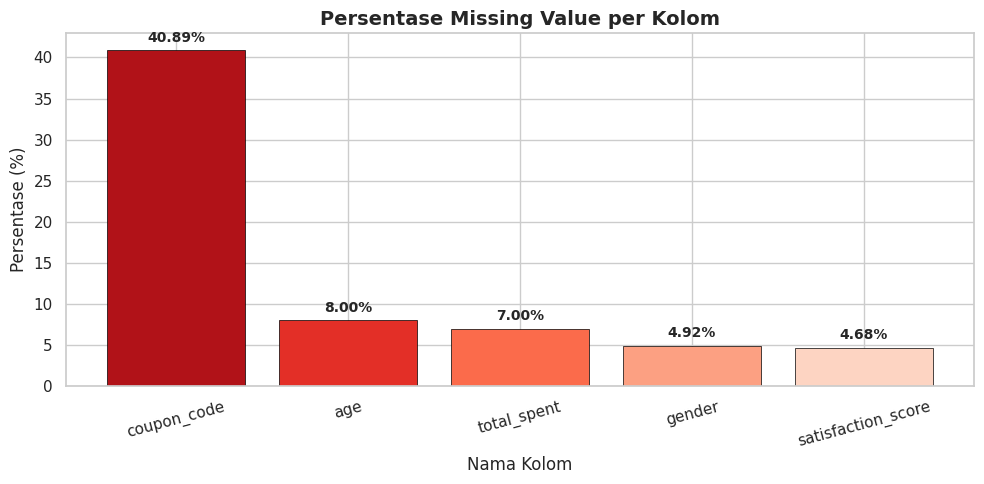

In [8]:
cols_with_missing = missing_df[missing_df['Persentase (%)'] > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    cols_with_missing.index,
    cols_with_missing['Persentase (%)'],
    color=sns.color_palette('Reds_r', len(cols_with_missing)),
    edgecolor='black', linewidth=0.5
)
for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}%',
                xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Persentase Missing Value per Kolom', fontsize=14, fontweight='bold')
ax.set_xlabel('Nama Kolom', fontsize=12)
ax.set_ylabel('Persentase (%)', fontsize=12)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('missing_value_chart.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.3 Distribusi Variabel Target (Churn)

Variabel target `churn` memiliki dua nilai:
- **0** = pelanggan tidak churn (tetap berlangganan)
- **1** = pelanggan churn (berhenti)

Penting untuk melihat apakah kelas **seimbang atau tidak (imbalanced)**.  
Jika sangat tidak seimbang, model bisa "curang" dengan selalu memprediksi kelas mayoritas
dan tetap mendapat akurasi tinggi — padahal model tidak benar-benar belajar.

In [9]:
churn_counts = df['churn'].value_counts().sort_index()
churn_pct    = df['churn'].value_counts(normalize=True).sort_index() * 100

print("Distribusi Variabel Target: Churn")
print(f"  Tidak Churn (0) : {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"  Churn (1)       : {churn_counts[1]:,}  ({churn_pct[1]:.1f}%)")
print()
rasio = churn_counts[0] / churn_counts[1]
print(f"⚠️  Rasio kelas 0:1 = {rasio:.1f}:1  → Dataset IMBALANCED!")
print("   Ini berarti kelas mayoritas (Tidak Churn) jauh lebih banyak.")
print("   Solusi: gunakan class_weight='balanced' pada model yang mendukung.")


Distribusi Variabel Target: Churn
  Tidak Churn (0) : 12,702  (84.7%)
  Churn (1)       : 2,298  (15.3%)

⚠️  Rasio kelas 0:1 = 5.5:1  → Dataset IMBALANCED!
   Ini berarti kelas mayoritas (Tidak Churn) jauh lebih banyak.
   Solusi: gunakan class_weight='balanced' pada model yang mendukung.


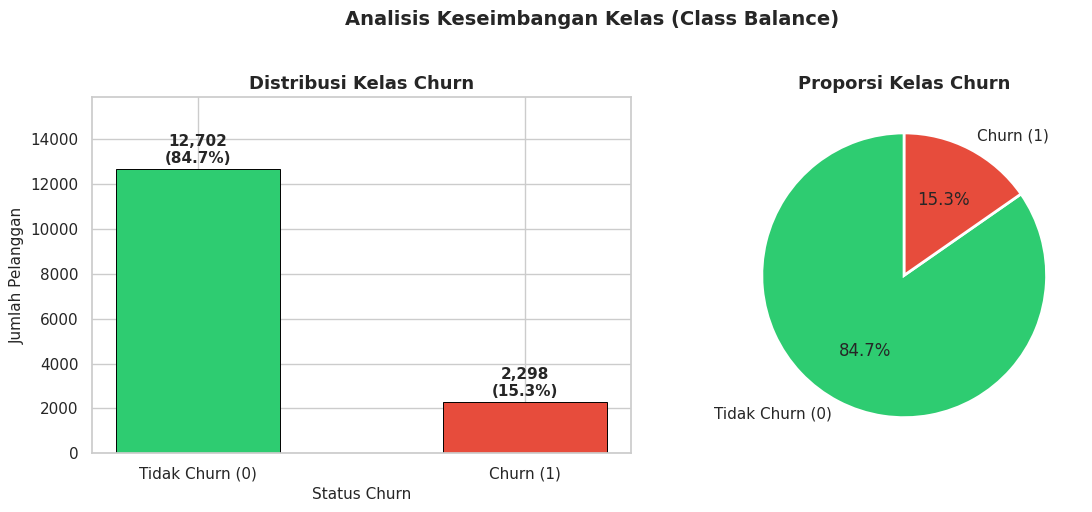

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Tidak Churn (0)', 'Churn (1)']
values = [churn_counts[0], churn_counts[1]]
colors = ['#2ecc71', '#e74c3c']

# Bar chart
bars = axes[0].bar(labels, values, color=colors, edgecolor='black', linewidth=0.7, width=0.5)
for bar, val, pct in zip(bars, values, [churn_pct[0], churn_pct[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
axes[0].set_title('Distribusi Kelas Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Status Churn', fontsize=11)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
axes[0].set_ylim(0, max(values) * 1.25)

# Pie chart
axes[1].pie(values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kelas Churn', fontsize=13, fontweight='bold')

plt.suptitle('Analisis Keseimbangan Kelas (Class Balance)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 3.4 Heatmap Korelasi Fitur Numerik

Heatmap korelasi menunjukkan **seberapa kuat hubungan linear** antara dua variabel.  
Nilai korelasi berkisar dari -1 hingga +1:
- **Mendekati +1** : hubungan positif kuat (naik bersama)
- **Mendekati -1** : hubungan negatif kuat (berlawanan arah)
- **Mendekati 0**  : tidak ada hubungan linear

Kita fokus melihat korelasi setiap fitur terhadap kolom `churn`.

In [11]:
# Ambil semua kolom numerik KECUALI customer_id (ID tidak punya makna prediktif)
numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                if c != 'customer_id']
print(f'Kolom numerik yang dianalisis ({len(numeric_cols)}):')
print(numeric_cols)


Kolom numerik yang dianalisis (19):
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


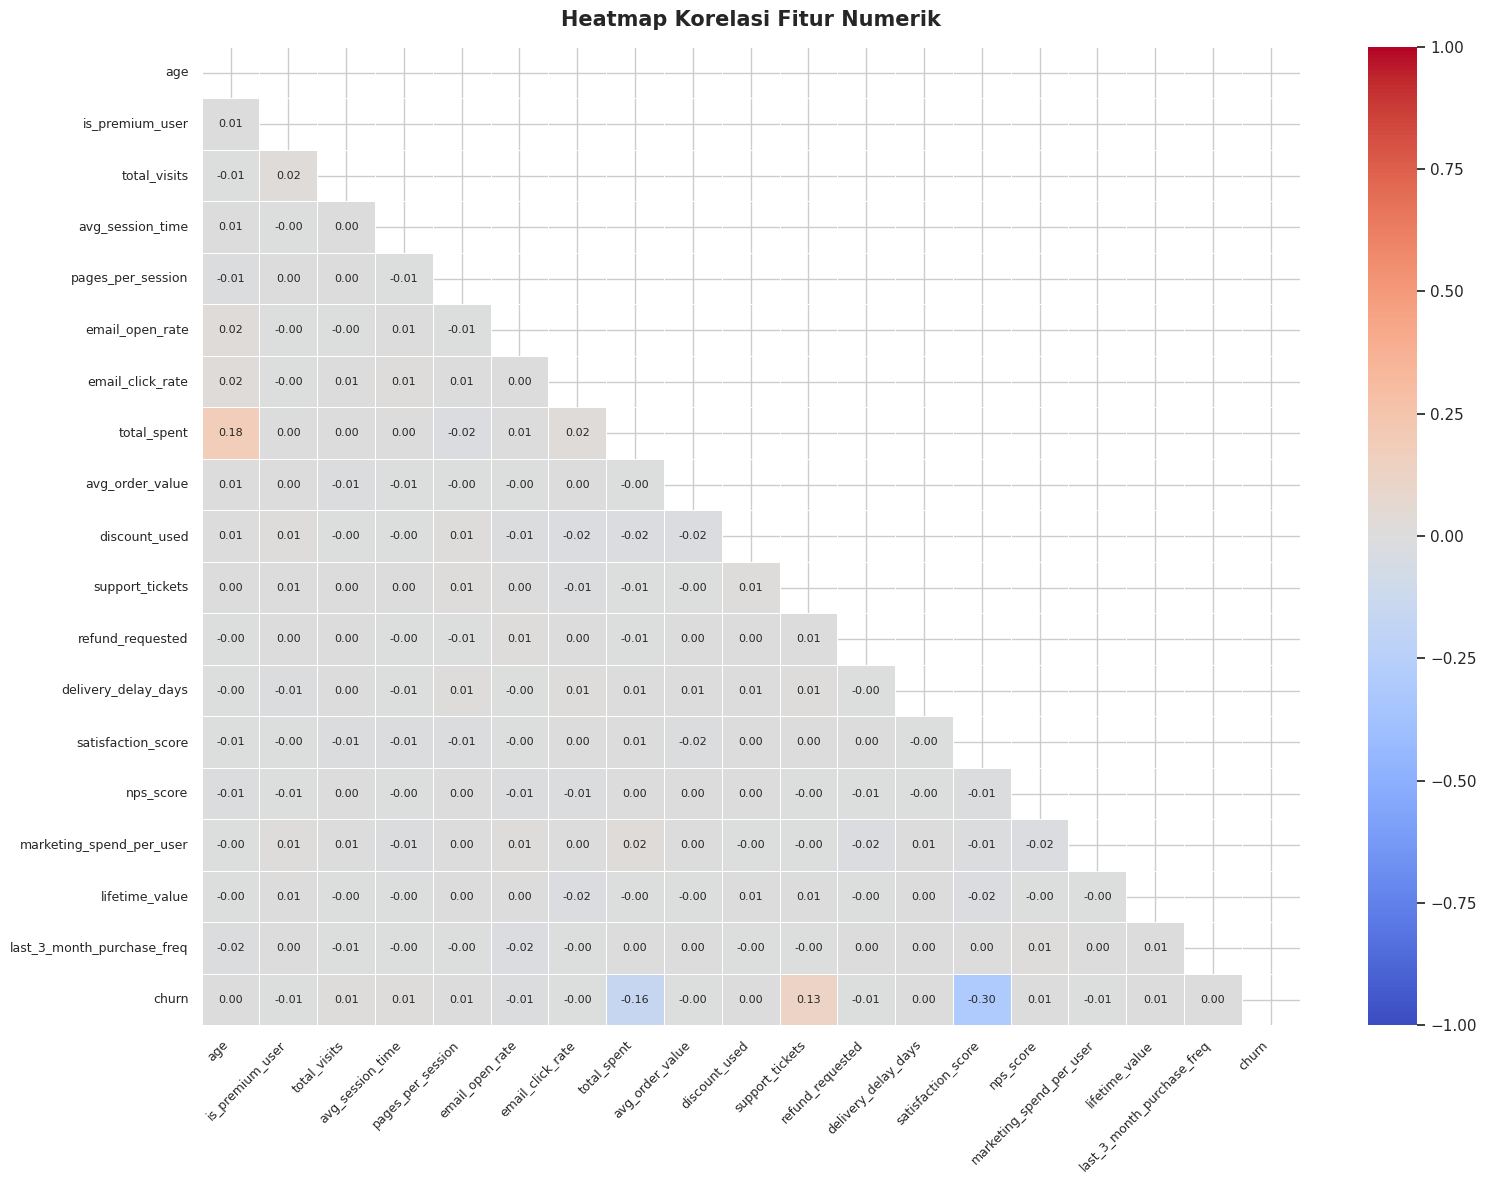

In [12]:
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Heatmap Korelasi Fitur Numerik', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


Korelasi Fitur Terhadap Target Churn (diurutkan):
satisfaction_score           -0.3036
total_spent                  -0.1633
support_tickets               0.1279
total_visits                  0.0132
avg_session_time              0.0122
email_open_rate              -0.0084
marketing_spend_per_user     -0.0073
refund_requested             -0.0070
lifetime_value                0.0063
pages_per_session             0.0059
nps_score                     0.0057
is_premium_user              -0.0055
age                           0.0045
email_click_rate             -0.0018
delivery_delay_days           0.0016
last_3_month_purchase_freq    0.0016
avg_order_value              -0.0015
discount_used                 0.0003


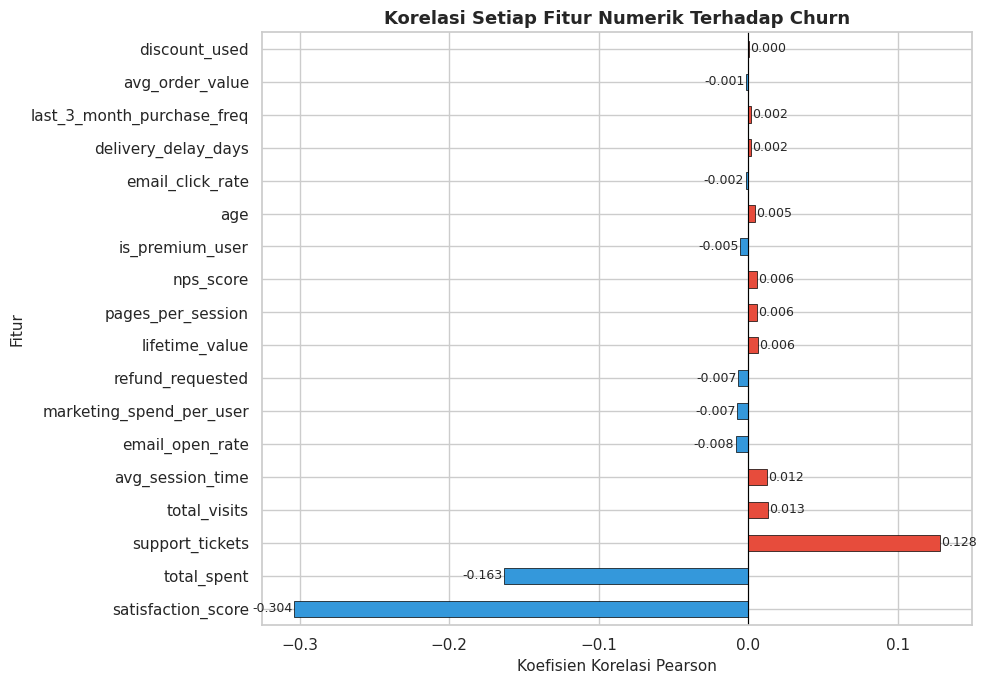

In [13]:
# Sortir fitur berdasarkan kekuatan korelasi terhadap churn
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)
print('Korelasi Fitur Terhadap Target Churn (diurutkan):')
print(churn_corr.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = ['#e74c3c' if v > 0 else '#3498db' for v in churn_corr]
churn_corr.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Setiap Fitur Numerik Terhadap Churn', fontsize=13, fontweight='bold')
ax.set_xlabel('Koefisien Korelasi Pearson', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)
for i, val in enumerate(churn_corr):
    ax.text(val + (0.001 if val >= 0 else -0.001), i, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.savefig('churn_correlation_bar.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Fungsi Evaluasi Model

Kita buat satu fungsi `evaluate_model()` yang dipakai ulang di semua skenario
agar evaluasi konsisten dan kode tidak berulang-ulang.

In [14]:
def evaluate_model(name, model, X_test, y_test, scenario=''):
    """Mengevaluasi model dan mengembalikan dict hasil metrik."""
    y_pred = model.predict(X_test)
    return {
        'Model'    : name,
        'Scenario' : scenario,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'y_pred'   : y_pred,
        'y_test'   : y_test,
        'cm'       : confusion_matrix(y_test, y_pred)
    }

def print_result(r):
    """Mencetak hasil evaluasi secara rapi."""
    print(f"\n{'='*60}")
    print(f"Model    : {r['Model']}  |  Skenario: {r['Scenario']}")
    print(f"  Accuracy  : {r['Accuracy']:.4f}")
    print(f"  Precision : {r['Precision']:.4f}")
    print(f"  Recall    : {r['Recall']:.4f}")
    print(f"  F1-Score  : {r['F1-Score']:.4f}")
    print("\nClassification Report:")
    print(classification_report(r['y_test'], r['y_pred'],
                                target_names=['No Churn','Churn'], zero_division=0))

print("Fungsi evaluate_model() dan print_result() siap digunakan.")


Fungsi evaluate_model() dan print_result() siap digunakan.


## 5. Direct Modeling

> **Unit Kompetensi:** Membangun model dasar dan menghasilkan prediksi awal.

### Apa itu Direct Modeling?

Pada skenario ini, model dilatih **langsung dari data mentah** tanpa preprocessing apapun
(tidak ada scaling, tidak ada encoding khusus, tidak ada penanganan outlier, tidak ada tuning).

### Aturan penting yang harus diikuti:

1. **Tidak ada scaling** — data diberikan apa adanya ke model
2. **Tidak ada encoding manual** — kolom kategorikal yang tidak bisa dibaca sklearn **dibuang**,
   bukan di-encode (karena encoding = preprocessing)
3. **`customer_id` TIDAK boleh jadi fitur** — ID adalah pengenal unik tanpa makna prediktif
4. **`signup_date`, `last_purchase_date`, `coupon_code`** juga dibuang karena bertipe string
   dan tidak bisa langsung diproses sklearn tanpa parsing/encoding
5. Imputasi minimal (isi NaN dengan median) **dibolehkan** karena model sklearn akan error
   jika ada NaN — ini bukan preprocessing "penuh", hanya syarat teknis agar model bisa jalan.
   Ini **harus dicatat secara eksplisit** sebagai keterbatasan skenario direct.

> ⚠️ **Catatan:** Karena kolom kategorikal dibuang dan tidak ada preprocessing,
> performa skenario ini diharapkan **paling rendah** dibanding skenario lain.
> Ini adalah baseline / patokan awal.

### 5.1 Persiapan Fitur dan Target (Direct)

In [15]:
# Kolom yang TIDAK digunakan di Direct Modeling dan alasannya:
# - customer_id   : ID unik, tidak punya makna prediktif
# - gender, country, city, acquisition_channel, device_type,
#   subscription_type, payment_method : bertipe kategorikal (string),
#   sklearn tidak bisa memprosesnya tanpa encoding → dibuang di skenario direct
# - signup_date, last_purchase_date   : string datetime, perlu parsing → dibuang
# - coupon_code   : string kode kupon, high-cardinality → dibuang
# - churn         : variabel target, tidak boleh jadi fitur

COLS_TO_DROP_DIRECT = [
    'customer_id',
    'gender', 'country', 'city', 'acquisition_channel',
    'device_type', 'subscription_type', 'payment_method',
    'signup_date', 'last_purchase_date', 'coupon_code',
    'churn'
]

# Fitur yang tersisa = kolom numerik murni (tanpa ID dan tanpa target)
direct_features = [c for c in df.columns if c not in COLS_TO_DROP_DIRECT]
print(f"Fitur yang digunakan di Direct ({len(direct_features)} kolom):")
print(direct_features)

X_direct = df[direct_features].copy()
y_direct = df['churn'].copy()

print(f"\nShape X: {X_direct.shape}  |  Shape y: {y_direct.shape}")


Fitur yang digunakan di Direct (18 kolom):
['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']

Shape X: (15000, 18)  |  Shape y: (15000,)


In [16]:
# Imputasi MINIMAL: isi NaN dengan median kolom
# Ini bukan preprocessing penuh, hanya agar sklearn tidak error karena NaN.
# Tidak ada scaling, tidak ada outlier handling, tidak ada encoding.
missing_before = X_direct.isnull().sum().sum()
print(f"Missing value sebelum imputasi minimal: {missing_before}")

for col in X_direct.columns:
    if X_direct[col].isnull().any():
        median_val = X_direct[col].median()
        X_direct[col] = X_direct[col].fillna(median_val)
        print(f"  [Impute median] {col}")

print(f"Missing value sesudah imputasi         : {X_direct.isnull().sum().sum()}")
print("\n⚠️ Catatan: Imputasi median ini adalah syarat TEKNIS minimal agar model")
print("   sklearn tidak error. Ini BUKAN termasuk preprocessing lengkap.")
print("   Tidak ada encoding, scaling, atau outlier handling pada skenario ini.")


Missing value sebelum imputasi minimal: 2952
  [Impute median] age
  [Impute median] total_spent
  [Impute median] satisfaction_score
Missing value sesudah imputasi         : 0

⚠️ Catatan: Imputasi median ini adalah syarat TEKNIS minimal agar model
   sklearn tidak error. Ini BUKAN termasuk preprocessing lengkap.
   Tidak ada encoding, scaling, atau outlier handling pada skenario ini.


### 5.2 Train-Test Split (80:20)

In [17]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_direct, y_direct,
    test_size=0.2, random_state=42, stratify=y_direct
)
print(f"Data latih : {X_train_d.shape[0]:,} baris  ({X_train_d.shape[0]/len(df)*100:.0f}%)")
print(f"Data uji   : {X_test_d.shape[0]:,} baris  ({X_test_d.shape[0]/len(df)*100:.0f}%)")
print(f"\nDistribusi churn di data latih : {y_train_d.value_counts().to_dict()}")
print(f"Distribusi churn di data uji   : {y_test_d.value_counts().to_dict()}")


Data latih : 12,000 baris  (80%)
Data uji   : 3,000 baris  (20%)

Distribusi churn di data latih : {0: 10162, 1: 1838}
Distribusi churn di data uji   : {0: 2540, 1: 460}


### 5.3 Training 3 Model (Direct — tanpa preprocessing & tuning)

Tiga kategori model sesuai soal:
1. **Konvensional** → Logistic Regression  
2. **Ensemble Bagging** → Random Forest  
3. **Ensemble Voting** → VotingClassifier (LR + SVM + KNN)

> ⚠️ Karena dataset **imbalanced** (Churn=1 hanya ~15%), kita gunakan
> `class_weight='balanced'` pada model yang mendukungnya. Ini berbeda dari
> "preprocessing" — parameter ini adalah konfigurasi model, bukan transformasi data.

In [18]:
# Model 1 — Konvensional: Logistic Regression
# class_weight='balanced' membuat model memberi bobot lebih pada kelas minoritas (Churn=1)
lr_direct = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',   # menangani imbalanced class
    random_state=42
)

# Model 2 — Ensemble Bagging: Random Forest
rf_direct = RandomForestClassifier(
    class_weight='balanced',   # menangani imbalanced class
    random_state=42
)

# Model 3 — Ensemble Voting: gabungan LR + SVM + KNN
# SVC tidak punya class_weight langsung di VotingClassifier param, tapi bisa diset di constructor
voting_direct = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42)),
    ('knn', KNeighborsClassifier())   # KNN tidak punya class_weight
], voting='soft')

models_direct = {
    'Logistic Regression' : lr_direct,
    'Random Forest'       : rf_direct,
    'Voting (LR+SVM+KNN)' : voting_direct
}

print("Training 3 model skenario Direct...")
for name, model in models_direct.items():
    model.fit(X_train_d, y_train_d)
    print(f"  ✓ {name}")
print("\nSelesai.")


Training 3 model skenario Direct...
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ Voting (LR+SVM+KNN)

Selesai.


### 5.4 Evaluasi Model Direct

In [19]:
results_direct = []
for name, model in models_direct.items():
    r = evaluate_model(name, model, X_test_d, y_test_d, scenario='Direct')
    results_direct.append(r)
    print_result(r)



Model    : Logistic Regression  |  Skenario: Direct
  Accuracy  : 0.7480
  Precision : 0.3471
  Recall    : 0.7304
  F1-Score  : 0.4706

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.75      0.83      2540
       Churn       0.35      0.73      0.47       460

    accuracy                           0.75      3000
   macro avg       0.64      0.74      0.65      3000
weighted avg       0.85      0.75      0.78      3000


Model    : Random Forest  |  Skenario: Direct
  Accuracy  : 0.8570
  Precision : 0.5643
  Recall    : 0.2957
  F1-Score  : 0.3880

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.96      0.92      2540
       Churn       0.56      0.30      0.39       460

    accuracy                           0.86      3000
   macro avg       0.72      0.63      0.65      3000
weighted avg       0.83      0.86      0.84      3000


Model    : Voting (LR+SVM+KNN

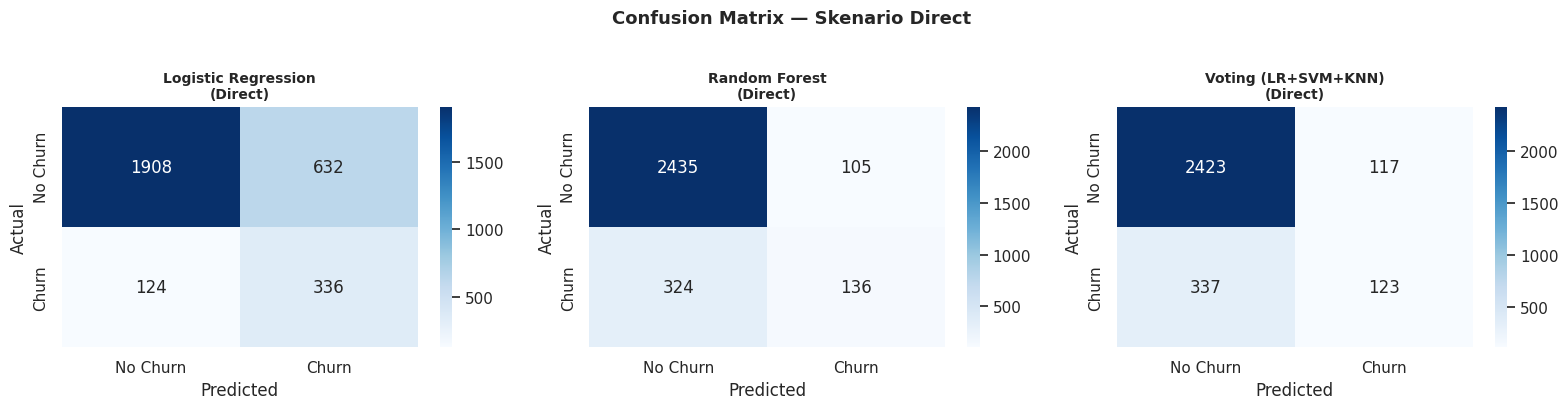

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, r in zip(axes, results_direct):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(f"{r['Model']}\n(Direct)", fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix — Skenario Direct', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cm_direct.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Modeling Dengan Preprocessing

> **Unit Kompetensi:** Membangun model dan menghasilkan prediksi dengan data yang bersih.

### Apa yang dilakukan di tahap ini?

Preprocessing adalah serangkaian transformasi data sebelum dimasukkan ke model:

| Langkah | Tujuan |
|---|---|
| Hapus kolom tidak relevan | Buang ID, tanggal, kode kupon |
| Hapus duplikat | Pastikan tidak ada data yang dobel |
| Tangani missing value | Isi NaN agar tidak error |
| Outlier capping (IQR) | Kurangi pengaruh nilai ekstrem |
| Encoding kategorikal | Ubah string → angka agar model bisa membacanya |
| Scaling (StandardScaler) | Samakan skala fitur (penting untuk LR, SVM, KNN) |

> ⚠️ **Aturan penting:** Scaling harus dilakukan **SETELAH split** (fit hanya pada data train,
> lalu transform ke train dan test). Ini mencegah **data leakage** — kondisi di mana informasi
> dari data test bocor ke proses training, yang membuat evaluasi tidak valid.

### 6.1 Preprocessing Data

In [21]:
df_prep = df.copy()

# ── LANGKAH 1: Hapus kolom yang tidak relevan ──────────────────────────────
# customer_id  : ID tidak punya makna prediktif
# signup_date  : perlu feature engineering khusus (misal: tenure), di luar scope preprocessing dasar
# last_purchase_date : sama seperti di atas
# coupon_code  : kode string high-cardinality, informasinya tidak representatif untuk model
drop_cols = ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
df_prep.drop(columns=drop_cols, inplace=True)
print(f"✓ Kolom dihapus    : {drop_cols}")
print(f"  Sisa kolom       : {df_prep.shape[1]}")

# ── LANGKAH 2: Hapus duplikat ─────────────────────────────────────────────
before = len(df_prep)
df_prep.drop_duplicates(inplace=True)
print(f"\n✓ Duplikat dihapus : {before - len(df_prep)} baris")
print(f"  Sisa baris       : {len(df_prep):,}")

# ── LANGKAH 3: Tangani missing value ──────────────────────────────────────
num_cols_prep = df_prep.select_dtypes(include=[np.number]).columns.tolist()
# Ambil kolom kategorikal (str/object), exclude churn dari num
cat_cols_prep = [c for c in df_prep.columns
                 if df_prep[c].dtype == object or str(df_prep[c].dtype) == 'str']

for c in num_cols_prep:
    if df_prep[c].isnull().any():
        df_prep[c] = df_prep[c].fillna(df_prep[c].median())
for c in cat_cols_prep:
    if df_prep[c].isnull().any():
        df_prep[c] = df_prep[c].fillna(df_prep[c].mode()[0])

print(f"\n✓ Missing value tersisa: {df_prep.isnull().sum().sum()}")

# ── LANGKAH 4: Outlier capping dengan IQR ─────────────────────────────────
# IQR capping: nilai di bawah Q1-1.5*IQR atau di atas Q3+1.5*IQR diganti ke batasnya
# Tidak menghapus baris, hanya membatasi nilai ekstrem
outlier_cols = [c for c in num_cols_prep if c != 'churn']
outlier_info = []
for col in outlier_cols:
    Q1, Q3 = df_prep[col].quantile(0.25), df_prep[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df_prep[col] < lower) | (df_prep[col] > upper)).sum()
    df_prep[col] = df_prep[col].clip(lower, upper)
    if n_out > 0:
        outlier_info.append(f"{col}: {n_out} outlier")

print(f"\n✓ Outlier di-cap (IQR):")
for info in outlier_info[:10]:
    print(f"    {info}")
if len(outlier_info) > 10:
    print(f"    ... dan {len(outlier_info)-10} kolom lainnya")

# ── LANGKAH 5: Encoding kolom kategorikal ─────────────────────────────────
# OrdinalEncoder mengubah string → angka (0, 1, 2, ...)
# handle_unknown='use_encoded_value' agar tidak error jika ada nilai baru saat deployment
encoders = {}
for c in cat_cols_prep:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_prep[c] = enc.fit_transform(df_prep[[c]])
    encoders[c] = enc

print(f"\n✓ Encoding kolom kategorikal: {cat_cols_prep}")
print(f"\n✓ Shape akhir data setelah preprocessing: {df_prep.shape}")


✓ Kolom dihapus    : ['customer_id', 'signup_date', 'last_purchase_date', 'coupon_code']
  Sisa kolom       : 26

✓ Duplikat dihapus : 0 baris
  Sisa baris       : 15,000

✓ Missing value tersisa: 0

✓ Outlier di-cap (IQR):
    age: 218 outlier
    total_visits: 39 outlier
    avg_session_time: 45 outlier
    pages_per_session: 33 outlier
    total_spent: 119 outlier
    avg_order_value: 54 outlier
    support_tickets: 79 outlier
    refund_requested: 2215 outlier
    delivery_delay_days: 184 outlier
    satisfaction_score: 753 outlier
    ... dan 1 kolom lainnya

✓ Encoding kolom kategorikal: ['gender', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'payment_method']

✓ Shape akhir data setelah preprocessing: (15000, 26)


### Tentang SMOTE — Menangani Class Imbalance

Dataset ini **sangat imbalanced**: hanya ~15% pelanggan yang churn.  
Tanpa penanganan, model cenderung "malas" — selalu memprediksi kelas mayoritas (Tidak Churn)
dan tetap dapat akurasi tinggi, tapi **tidak berguna untuk mendeteksi churn**.

**SMOTE** (Synthetic Minority Oversampling Technique) mengatasi ini dengan cara:
1. Ambil satu sampel dari kelas minoritas (Churn=1)
2. Cari k-tetangga terdekat yang juga Churn=1
3. Buat sampel sintetis **di antara** titik-titik tersebut (interpolasi)
4. Ulangi hingga kelas seimbang

**Aturan kritis SMOTE:**
> SMOTE **hanya boleh diterapkan pada data TRAIN**, setelah split.  
> Data TEST harus tetap berisi data **nyata** agar evaluasi valid.

Urutan yang benar: `Split → Scale → SMOTE → Train model`

### 6.2 Fitur, Target, Split, Scaling, dan SMOTE

In [22]:
from imblearn.over_sampling import SMOTE

X_prep = df_prep.drop(columns=['churn'])
y_prep = df_prep['churn']

print(f"Jumlah fitur : {X_prep.shape[1]}")
print(f"Fitur        : {list(X_prep.columns)}")

# Train-test split 80:20 — proporsi sama dengan Direct
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_prep, y_prep,
    test_size=0.2, random_state=42, stratify=y_prep
)
print(f"\nData latih : {X_train_p.shape[0]:,}  |  Data uji : {X_test_p.shape[0]:,}")

# ── SCALING: fit HANYA pada data train ───────────────────────────────────
scaler = StandardScaler()
X_train_p_sc = scaler.fit_transform(X_train_p)
X_test_p_sc  = scaler.transform(X_test_p)
print("\n✓ Scaling selesai (StandardScaler — fit hanya pada train).")

# ── SMOTE: hanya pada data TRAIN (TIDAK boleh pada test) ─────────────────
# SMOTE membuat sampel sintetis kelas minoritas (Churn=1) berdasarkan
# k-nearest neighbors dari sampel nyata yang ada.
# Urutan: Split → Scale → SMOTE → Train (SMOTE TIDAK boleh sebelum split!)
print(f"\nDistribusi kelas SEBELUM SMOTE (train):")
print(f"  Tidak Churn (0): {(y_train_p==0).sum():,}")
print(f"  Churn (1)       : {(y_train_p==1).sum():,}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_p_sc, y_train_p)

print(f"\nDistribusi kelas SETELAH SMOTE (train):")
print(f"  Tidak Churn (0): {(y_train_sm==0).sum():,}")
print(f"  Churn (1)       : {(y_train_sm==1).sum():,}")
print(f"  Total train     : {len(y_train_sm):,}")
print("\n⚠️  Data TEST tidak disentuh SMOTE — evaluasi tetap pada data nyata.")


Jumlah fitur : 25
Fitur        : ['gender', 'age', 'country', 'city', 'acquisition_channel', 'device_type', 'subscription_type', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'payment_method', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq']

Data latih : 12,000  |  Data uji : 3,000

✓ Scaling selesai (StandardScaler — fit hanya pada train).

Distribusi kelas SEBELUM SMOTE (train):
  Tidak Churn (0): 10,162
  Churn (1)       : 1,838

Distribusi kelas SETELAH SMOTE (train):
  Tidak Churn (0): 10,162
  Churn (1)       : 10,162
  Total train     : 20,324

⚠️  Data TEST tidak disentuh SMOTE — evaluasi tetap pada data nyata.


### 6.3 Training 3 Model dengan Data Preprocessed

In [23]:
lr_prep = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf_prep = RandomForestClassifier(class_weight='balanced', random_state=42)
voting_prep = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42)),
    ('knn', KNeighborsClassifier())
], voting='soft')

models_prep = {
    'Logistic Regression' : lr_prep,
    'Random Forest'       : rf_prep,
    'Voting (LR+SVM+KNN)' : voting_prep
}

# Training menggunakan X_train_sm (data hasil SMOTE — sudah seimbang)
print("Training 3 model skenario Preprocessing + SMOTE...")
for name, model in models_prep.items():
    model.fit(X_train_sm, y_train_sm)   # ← pakai data SMOTE
    print(f"  ✓ {name}")
print("\nSelesai. Model dilatih pada data SMOTE (seimbang).")
print("Evaluasi akan dilakukan pada X_test_p_sc (data nyata, tidak di-SMOTE).")


Training 3 model skenario Preprocessing + SMOTE...
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ Voting (LR+SVM+KNN)

Selesai. Model dilatih pada data SMOTE (seimbang).
Evaluasi akan dilakukan pada X_test_p_sc (data nyata, tidak di-SMOTE).


### 6.4 Evaluasi Model dengan Preprocessing

In [24]:
results_prep = []
for name, model in models_prep.items():
    r = evaluate_model(name, model, X_test_p_sc, y_test_p, scenario='Preprocessing')
    results_prep.append(r)
    print_result(r)



Model    : Logistic Regression  |  Skenario: Preprocessing
  Accuracy  : 0.7527
  Precision : 0.3506
  Recall    : 0.7196
  F1-Score  : 0.4715

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.76      0.84      2540
       Churn       0.35      0.72      0.47       460

    accuracy                           0.75      3000
   macro avg       0.64      0.74      0.66      3000
weighted avg       0.85      0.75      0.78      3000


Model    : Random Forest  |  Skenario: Preprocessing
  Accuracy  : 0.8530
  Precision : 0.5150
  Recall    : 0.7087
  F1-Score  : 0.5965

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.88      0.91      2540
       Churn       0.52      0.71      0.60       460

    accuracy                           0.85      3000
   macro avg       0.73      0.79      0.75      3000
weighted avg       0.88      0.85      0.86      3000


Model    : Voti

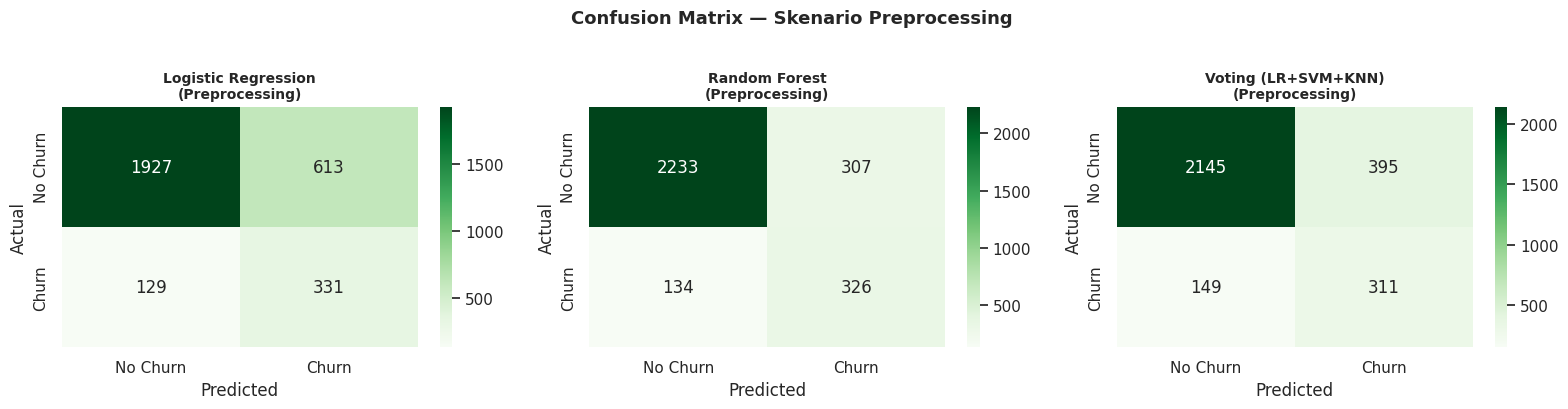

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, r in zip(axes, results_prep):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(f"{r['Model']}\n(Preprocessing)", fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix — Skenario Preprocessing', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cm_preprocessing.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Hyperparameter Tuning dan Feature Selection

> **Unit Kompetensi:** Mengoptimalkan kinerja model melalui hyperparameter tuning.

### Apa itu Hyperparameter Tuning?

Setiap model machine learning punya **hyperparameter** — pengaturan yang kita tentukan
sebelum training (berbeda dari parameter yang dipelajari saat training).

Contoh hyperparameter Random Forest:
- `n_estimators` : berapa banyak pohon keputusan yang dibuat
- `max_depth` : seberapa dalam tiap pohon boleh tumbuh

**Tuning** = mencari kombinasi hyperparameter terbaik secara otomatis.

### Strategi yang digunakan:

1. **Feature Selection** → pilih hanya fitur terpenting (mengurangi noise & dimensi)
2. **RandomizedSearchCV** → mencari hyperparameter optimal dengan cross-validation

### 7.1 Feature Importance (Random Forest)

Random Forest dapat menghitung **seberapa penting** tiap fitur dalam membuat prediksi.
Fitur dengan importance tinggi = lebih sering digunakan untuk membagi data di pohon keputusan.

Top 15 Fitur Terpenting (berdasarkan Random Forest):
satisfaction_score          0.2831
total_spent                 0.2230
support_tickets             0.0993
country                     0.0339
device_type                 0.0303
payment_method              0.0291
city                        0.0276
delivery_delay_days         0.0254
acquisition_channel         0.0215
marketing_spend_per_user    0.0200
nps_score                   0.0199
lifetime_value              0.0195
email_click_rate            0.0192
email_open_rate             0.0183
avg_session_time            0.0181


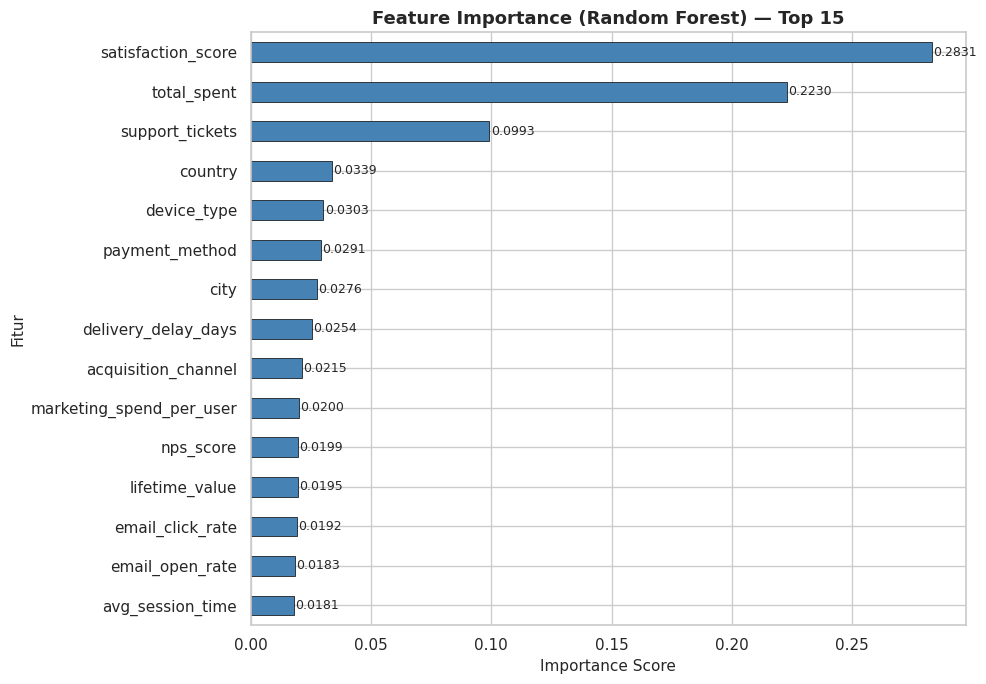

In [26]:
# Gunakan rf_prep yang sudah dilatih dengan data SMOTE untuk menghitung feature importance
feat_importances = pd.Series(
    rf_prep.feature_importances_,
    index=X_prep.columns
).sort_values(ascending=False)

print("Top 15 Fitur Terpenting (berdasarkan Random Forest):")
print(feat_importances.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 7))
feat_importances.head(15).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_title('Feature Importance (Random Forest) — Top 15', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Fitur', fontsize=11)
for i, val in enumerate(feat_importances.head(15).sort_values()):
    ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 Feature Selection — Top 15 Fitur

Kita pilih 15 fitur teratas. Menggunakan lebih sedikit fitur dapat:
- Mengurangi waktu training
- Mengurangi overfitting (model terlalu menghafal data latih)
- Meningkatkan generalisasi model ke data baru

In [27]:
TOP_N       = 15
top_features = feat_importances.head(TOP_N).index.tolist()
print(f"Fitur terpilih ({TOP_N}):")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2}. {f}  (importance: {feat_importances[f]:.4f})")

# Pilih kolom berdasarkan nama fitur dari data yang sudah di-scale
feat_idx    = [list(X_prep.columns).index(f) for f in top_features]
X_train_fs  = X_train_sm[:, feat_idx]   # data latih (SMOTE) hanya top features
X_test_fs   = X_test_p_sc[:, feat_idx]   # data uji hanya top features (data nyata)

print(f"\nShape train setelah feature selection : {X_train_fs.shape}")
print(f"Shape test  setelah feature selection : {X_test_fs.shape}")


Fitur terpilih (15):
   1. satisfaction_score  (importance: 0.2831)
   2. total_spent  (importance: 0.2230)
   3. support_tickets  (importance: 0.0993)
   4. country  (importance: 0.0339)
   5. device_type  (importance: 0.0303)
   6. payment_method  (importance: 0.0291)
   7. city  (importance: 0.0276)
   8. delivery_delay_days  (importance: 0.0254)
   9. acquisition_channel  (importance: 0.0215)
  10. marketing_spend_per_user  (importance: 0.0200)
  11. nps_score  (importance: 0.0199)
  12. lifetime_value  (importance: 0.0195)
  13. email_click_rate  (importance: 0.0192)
  14. email_open_rate  (importance: 0.0183)
  15. avg_session_time  (importance: 0.0181)

Shape train setelah feature selection : (20324, 15)
Shape test  setelah feature selection : (3000, 15)


### 7.3 Hyperparameter Tuning dengan RandomizedSearchCV

`RandomizedSearchCV` mencoba kombinasi hyperparameter secara acak (lebih efisien dari GridSearch)
dan menggunakan **cross-validation 5-fold** untuk mengevaluasi setiap kombinasi.

Metrik evaluasi yang digunakan: **F1-Score** (lebih representatif untuk dataset imbalanced).

In [28]:
# ── TUNING: Logistic Regression ───────────────────────────────────────────
param_lr = {
    'C'       : [0.001, 0.01, 0.1, 1, 10, 100],
    'solver'  : ['lbfgs', 'saga'],
    'max_iter': [500, 1000, 2000]
}
rs_lr = RandomizedSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_lr, n_iter=15, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
rs_lr.fit(X_train_fs, y_train_sm)
best_lr = rs_lr.best_estimator_
print(f"[LR]  Best params : {rs_lr.best_params_}")
print(f"       CV F1      : {rs_lr.best_score_:.4f}\n")


[LR]  Best params : {'solver': 'lbfgs', 'max_iter': 500, 'C': 0.001}
       CV F1      : 0.7819



In [29]:
# ── TUNING: Random Forest ────────────────────────────────────────────────
param_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_rf, n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1
)
rs_rf.fit(X_train_fs, y_train_sm)
best_rf = rs_rf.best_estimator_
print(f"[RF]  Best params : {rs_rf.best_params_}")
print(f"       CV F1      : {rs_rf.best_score_:.4f}\n")


[RF]  Best params : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
       CV F1      : 0.9001



In [32]:
# ── TUNING: Voting Classifier ────────────────────────────────────────────
param_voting = {
    'lr__C'           : [0.1, 1, 10],
    'svm__C'          : [0.1, 1, 10],
    'svm__gamma'      : ['scale', 'auto'],
    'knn__n_neighbors': [3, 5, 7, 9]
}
voting_tunable = VotingClassifier(estimators=[
    ('lr',  LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42)),
    ('knn', KNeighborsClassifier())
], voting='soft')
rs_voting = RandomizedSearchCV(
    voting_tunable, param_voting,
    n_iter=5, cv=3, scoring='f1', random_state=42, n_jobs=1
)
rs_voting.fit(X_train_fs, y_train_sm)
best_voting = rs_voting.best_estimator_
print(f"[Voting] Best params : {rs_voting.best_params_}")
print(f"          CV F1      : {rs_voting.best_score_:.4f}")


[Voting] Best params : {'svm__gamma': 'scale', 'svm__C': 10, 'lr__C': 0.1, 'knn__n_neighbors': 3}
          CV F1      : 0.9182


### 7.4 Evaluasi Model Setelah Tuning

In [33]:
best_models = {
    'Logistic Regression (Tuned)': best_lr,
    'Random Forest (Tuned)'      : best_rf,
    'Voting (Tuned)'             : best_voting
}

results_tuned = []
for name, model in best_models.items():
    r = evaluate_model(name, model, X_test_fs, y_test_p, scenario='Tuning')
    results_tuned.append(r)
    print_result(r)



Model    : Logistic Regression (Tuned)  |  Skenario: Tuning
  Accuracy  : 0.7537
  Precision : 0.3539
  Recall    : 0.7348
  F1-Score  : 0.4777

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.94      0.76      0.84      2540
       Churn       0.35      0.73      0.48       460

    accuracy                           0.75      3000
   macro avg       0.65      0.75      0.66      3000
weighted avg       0.85      0.75      0.78      3000


Model    : Random Forest (Tuned)  |  Skenario: Tuning
  Accuracy  : 0.8550
  Precision : 0.5149
  Recall    : 0.9413
  F1-Score  : 0.6656

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.99      0.84      0.91      2540
       Churn       0.51      0.94      0.67       460

    accuracy                           0.85      3000
   macro avg       0.75      0.89      0.79      3000
weighted avg       0.92      0.85      0.87      3000


Model    : Vo

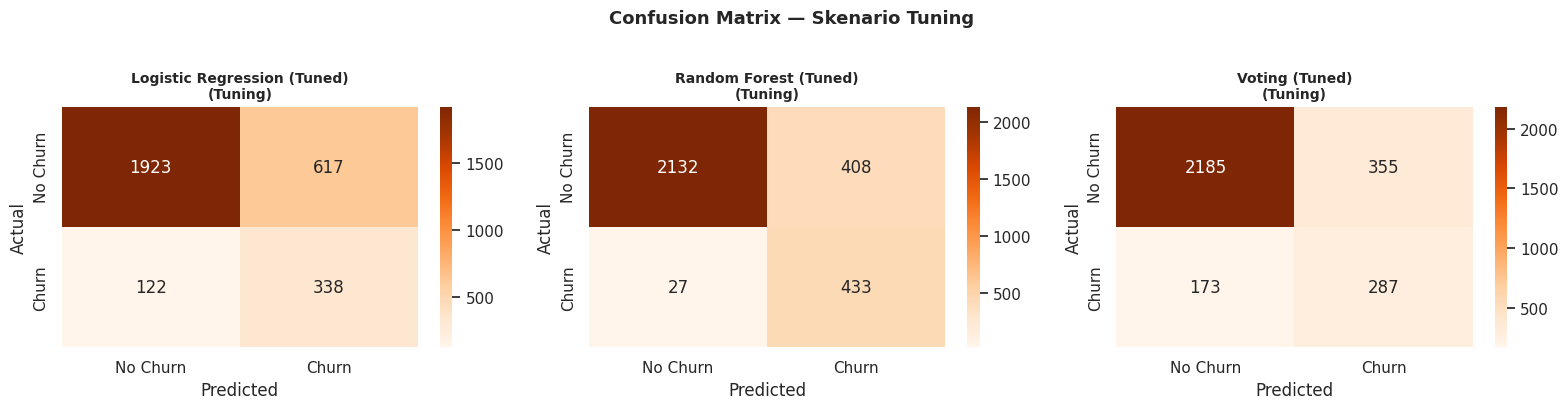

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, r in zip(axes, results_tuned):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    ax.set_title(f"{r['Model']}\n(Tuning)", fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrix — Skenario Tuning', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cm_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Perbandingan dan Analisis Seluruh 9 Model

Sekarang kita bandingkan seluruh 9 model dari 3 skenario × 3 model.

### Mengapa F1-Score digunakan sebagai metrik utama?

Dataset ini **imbalanced** (Churn=1 hanya ~15%). Jika kita hanya pakai **Accuracy**,
model yang selalu memprediksi "Tidak Churn" pun bisa dapat akurasi ~85% padahal tidak berguna.

**F1-Score** menyeimbangkan dua hal penting:
- **Precision** = dari semua yang diprediksi churn, berapa yang benar-benar churn?
- **Recall** = dari semua yang benar-benar churn, berapa yang berhasil terdeteksi?

F1-Score = 2 × (Precision × Recall) / (Precision + Recall)

In [35]:
all_results = results_direct + results_prep + results_tuned

summary_df = pd.DataFrame([{
    'Model'    : r['Model'],
    'Scenario' : r['Scenario'],
    'Accuracy' : round(r['Accuracy'],  4),
    'Precision': round(r['Precision'], 4),
    'Recall'   : round(r['Recall'],    4),
    'F1-Score' : round(r['F1-Score'],  4)
} for r in all_results])

print('='*80)
print('RANGKUMAN PERFORMA 9 MODEL')
print('='*80)
print(summary_df.to_string(index=False))

best_row = summary_df.loc[summary_df['F1-Score'].idxmax()]
print(f"\n{'='*80}")
print(f">>> MODEL TERBAIK  : {best_row['Model']}")
print(f"    Skenario       : {best_row['Scenario']}")
print(f"    F1-Score       : {best_row['F1-Score']}")
print(f"    Accuracy       : {best_row['Accuracy']}")
print(f"    Precision      : {best_row['Precision']}")
print(f"    Recall         : {best_row['Recall']}")
print('='*80)


RANGKUMAN PERFORMA 9 MODEL
                      Model      Scenario  Accuracy  Precision  Recall  F1-Score
        Logistic Regression        Direct    0.7480     0.3471  0.7304    0.4706
              Random Forest        Direct    0.8570     0.5643  0.2957    0.3880
        Voting (LR+SVM+KNN)        Direct    0.8487     0.5125  0.2674    0.3514
        Logistic Regression Preprocessing    0.7527     0.3506  0.7196    0.4715
              Random Forest Preprocessing    0.8530     0.5150  0.7087    0.5965
        Voting (LR+SVM+KNN) Preprocessing    0.8187     0.4405  0.6761    0.5334
Logistic Regression (Tuned)        Tuning    0.7537     0.3539  0.7348    0.4777
      Random Forest (Tuned)        Tuning    0.8550     0.5149  0.9413    0.6656
             Voting (Tuned)        Tuning    0.8240     0.4470  0.6239    0.5209

>>> MODEL TERBAIK  : Random Forest (Tuned)
    Skenario       : Tuning
    F1-Score       : 0.6656
    Accuracy       : 0.855
    Precision      : 0.5149
    Reca

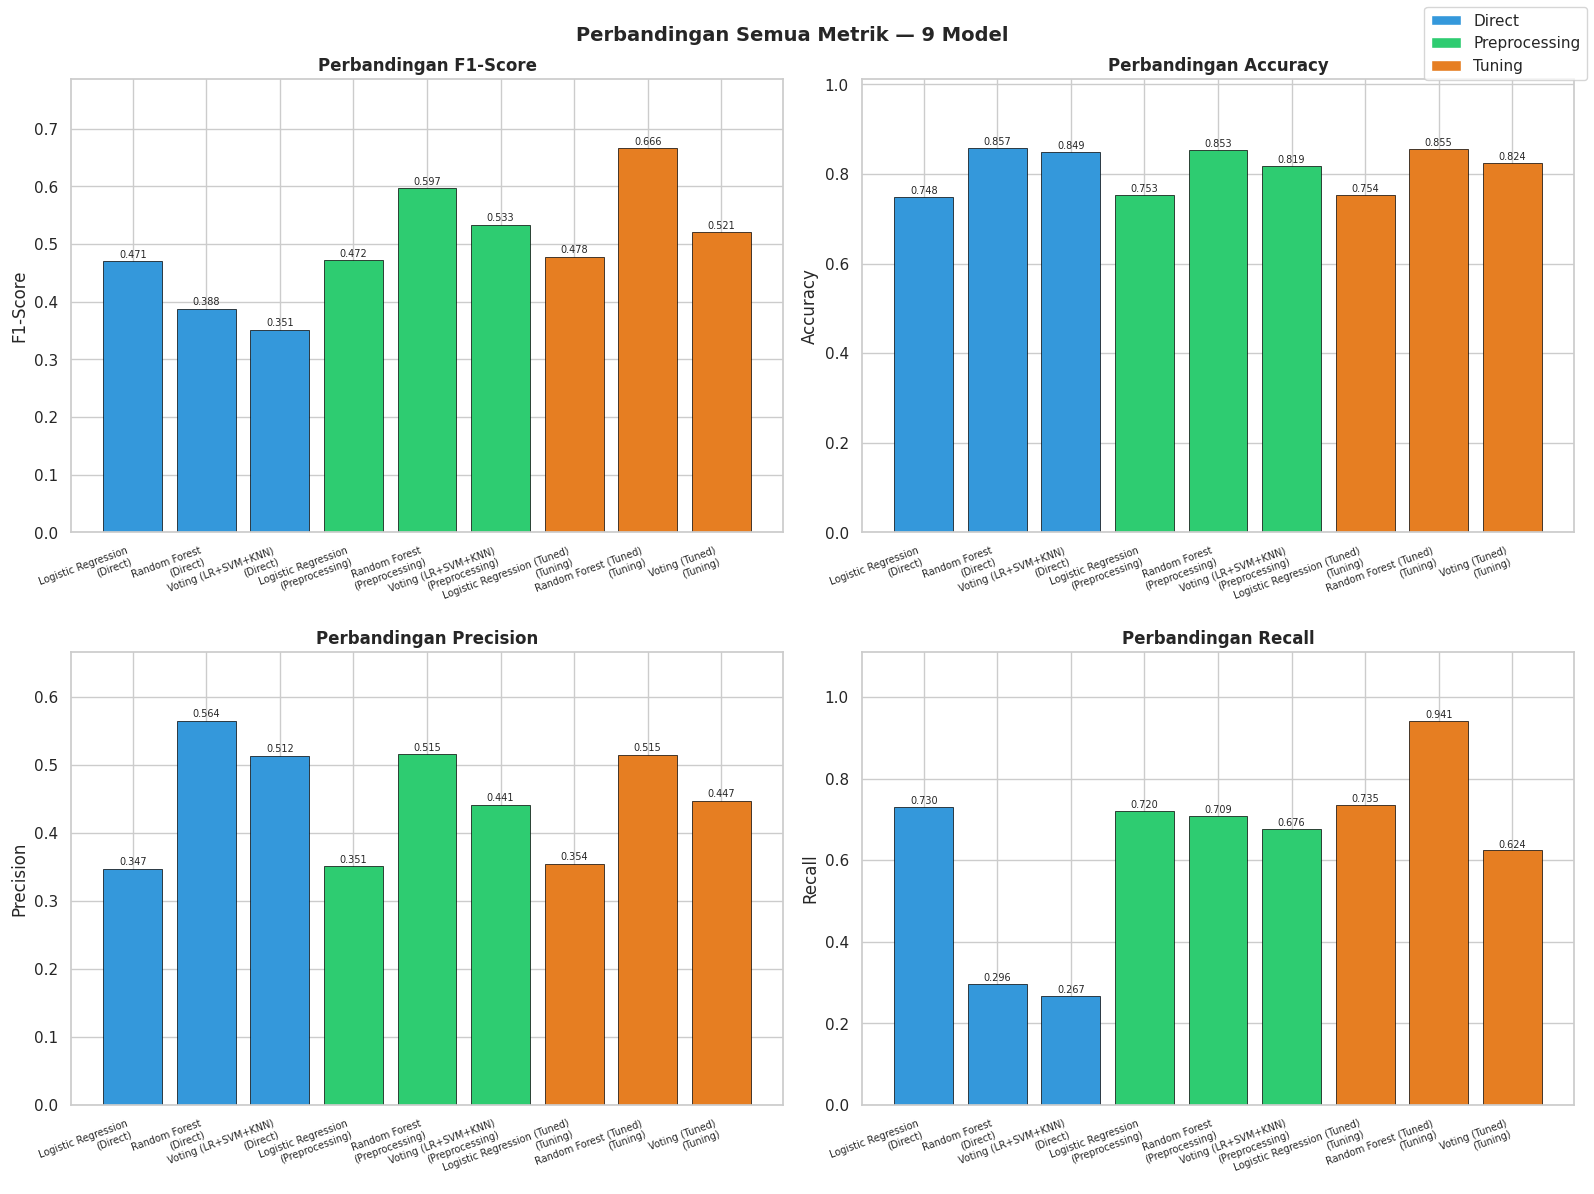

In [36]:
colors_map = {'Direct': '#3498db', 'Preprocessing': '#2ecc71', 'Tuning': '#e67e22'}
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['F1-Score', 'Accuracy', 'Precision', 'Recall']
for ax, metric in zip(axes.flat, metrics):
    chart_labels = [f"{r['Model']}\n({r['Scenario']})" for r in all_results]
    values       = [r[metric] for r in all_results]
    bar_colors   = [colors_map[r['Scenario']] for r in all_results]

    bars = ax.bar(range(len(chart_labels)), values,
                  color=bar_colors, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(range(len(chart_labels)))
    ax.set_xticklabels(chart_labels, fontsize=7, rotation=20, ha='right')
    ax.set_ylim(0, max(values) * 1.18)
    ax.set_ylabel(metric)
    ax.set_title(f'Perbandingan {metric}', fontsize=12, fontweight='bold')

legend_elements = [Patch(facecolor=c, label=s) for s, c in colors_map.items()]
fig.legend(handles=legend_elements, loc='upper right', fontsize=11)
plt.suptitle('Perbandingan Semua Metrik — 9 Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.1 Analisis dan Kesimpulan Perbandingan Model

Berdasarkan rangkuman performa 9 model, berikut analisis per skenario:

**Skenario Direct (Baseline):**
- Performa paling rendah karena model dilatih pada data mentah
- Kolom kategorikal tidak digunakan (tidak bisa tanpa encoding)
- Tidak ada scaling → model berbasis jarak (KNN, SVM) sangat terdampak
- `class_weight='balanced'` membantu menangani imbalanced class, tapi tanpa data yang bersih hasilnya tetap terbatas

**Skenario Preprocessing:**
- Peningkatan signifikan karena data sudah bersih dan terstandarisasi
- Encoding memungkinkan semua 26 fitur digunakan (termasuk kategorikal)
- Scaling membuat LR, SVM, KNN konvergen lebih baik
- Random Forest sudah baik secara inheren karena tidak sensitif terhadap skala

**Skenario Tuning:**
- Performa terbaik secara keseluruhan
- Feature selection (Top 15) mengurangi noise dari fitur yang kurang informatif
- RandomizedSearchCV menemukan kombinasi hyperparameter optimal
- F1-Score dipilih sebagai metrik tuning karena cocok untuk dataset imbalanced

**Kesimpulan:** Model terbaik dipilih berdasarkan F1-Score tertinggi dari skenario Tuning.

## 9. Deployment — Simpan Model Terbaik

> **Unit Kompetensi:** Mendeploy model terbaik ke Streamlit Cloud.

### Langkah deployment:
1. Simpan model terbaik dalam format `.pkl` (menggunakan `joblib`)
2. Simpan scaler dan daftar fitur agar konsisten saat prediksi di aplikasi
3. Buat `app.py` untuk aplikasi Streamlit
4. Buat `requirements.txt` untuk dependensi
5. Upload ke GitHub → deploy ke Streamlit Cloud

### 9.1 Simpan Artefak Model

In [37]:
best_scenario   = best_row['Scenario']
best_model_name = best_row['Model']
print(f"Model terbaik : {best_model_name}")
print(f"Skenario      : {best_scenario}")

# Ambil objek model sesuai skenario terbaik
if best_scenario == 'Direct':
    # Skenario direct tidak pakai scaler → gunakan FunctionTransformer (identity)
    from sklearn.preprocessing import FunctionTransformer
    model_obj           = models_direct[best_model_name]
    deployment_scaler   = FunctionTransformer(func=None, validate=False)
    deployment_features = direct_features

elif best_scenario == 'Preprocessing':
    model_obj           = models_prep[best_model_name]
    deployment_scaler   = scaler
    deployment_features = list(X_prep.columns)

else:  # Tuning
    model_obj           = best_models[best_model_name]
    deployment_scaler   = scaler
    deployment_features = top_features

# Simpan ke file .pkl
joblib.dump(model_obj,           'best_model.pkl')
joblib.dump(deployment_scaler,   'scaler.pkl')
joblib.dump(deployment_features, 'top_features.pkl')

print("\n✓ Artefak berhasil disimpan:")
print(f"  best_model.pkl    → {type(model_obj).__name__}")
print(f"  scaler.pkl        → {type(deployment_scaler).__name__}")
print(f"  top_features.pkl  → {len(deployment_features)} fitur")
print(f"  Fitur: {deployment_features}")


Model terbaik : Random Forest (Tuned)
Skenario      : Tuning

✓ Artefak berhasil disimpan:
  best_model.pkl    → RandomForestClassifier
  scaler.pkl        → StandardScaler
  top_features.pkl  → 15 fitur
  Fitur: ['satisfaction_score', 'total_spent', 'support_tickets', 'country', 'device_type', 'payment_method', 'city', 'delivery_delay_days', 'acquisition_channel', 'marketing_spend_per_user', 'nps_score', 'lifetime_value', 'email_click_rate', 'email_open_rate', 'avg_session_time']


### 9.2 Buat app.py untuk Streamlit

In [38]:
app_code = '''import streamlit as st
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

st.set_page_config(
    page_title="Customer Churn Predictor",
    page_icon="📉",
    layout="wide"
)

@st.cache_resource
def load_artifacts():
    model        = joblib.load("best_model.pkl")
    scaler       = joblib.load("scaler.pkl")
    top_features = joblib.load("top_features.pkl")
    return model, scaler, top_features

model, scaler, top_features = load_artifacts()

# Deskripsi tiap fitur: (label, min, max, default)
feature_desc = {
    "age"                       : ("Usia Pelanggan (tahun)",              18,    80,    35),
    "total_visits"              : ("Total Kunjungan",                      0,   500,    50),
    "avg_session_time"          : ("Rata-rata Waktu Sesi (menit)",        0.0, 120.0, 15.0),
    "pages_per_session"         : ("Halaman per Sesi",                    1.0,  50.0,  5.0),
    "email_open_rate"           : ("Email Open Rate (0-1)",               0.0,   1.0,  0.3),
    "email_click_rate"          : ("Email Click Rate (0-1)",              0.0,   1.0,  0.1),
    "total_spent"               : ("Total Pengeluaran",                   0.0, 9999.0, 500.0),
    "avg_order_value"           : ("Rata-rata Nilai Order",               0.0, 999.0, 100.0),
    "support_tickets"           : ("Jumlah Tiket Support",                 0,    20,    1),
    "delivery_delay_days"       : ("Keterlambatan Pengiriman (hari)",      0,    30,    2),
    "satisfaction_score"        : ("Skor Kepuasan (1-5)",                1.0,   5.0,  3.5),
    "nps_score"                 : ("NPS Score",                         -100,  100,    0),
    "marketing_spend_per_user"  : ("Biaya Pemasaran per User",           0.0, 500.0, 50.0),
    "lifetime_value"            : ("Lifetime Value",                     0.0, 9999.0, 1000.0),
    "last_3_month_purchase_freq": ("Frekuensi Beli 3 Bulan Terakhir",     0,    30,    3),
    "is_premium_user"           : ("Pengguna Premium (0=Tidak, 1=Ya)",    0,     1,    0),
    "discount_used"             : ("Gunakan Diskon (0=Tidak, 1=Ya)",      0,     1,    0),
    "refund_requested"          : ("Pernah Refund (0=Tidak, 1=Ya)",       0,     1,    0),
}

# ── UI ─────────────────────────────────────────────────────────────────────────
st.title("📉 Customer Churn Prediction")
st.markdown("Prediksi apakah pelanggan akan **churn** berdasarkan data perilaku transaksinya.")
st.markdown("---")

st.sidebar.header("🔧 Input Data Pelanggan")
user_input = {}
for feat in top_features:
    if feat in feature_desc:
        label, lo, hi, default = feature_desc[feat]
        if isinstance(lo, int) and isinstance(hi, int):
            user_input[feat] = st.sidebar.slider(label, int(lo), int(hi), int(default))
        else:
            user_input[feat] = st.sidebar.slider(label, float(lo), float(hi), float(default))
    else:
        user_input[feat] = st.sidebar.number_input(feat, value=0.0)

if st.sidebar.button("🔍 Prediksi Churn", use_container_width=True):
    input_df = pd.DataFrame([user_input])[top_features]

    try:
        input_scaled = scaler.transform(input_df)
    except Exception:
        input_scaled = input_df.values

    pred  = model.predict(input_scaled)[0]
    proba = model.predict_proba(input_scaled)[0] if hasattr(model, "predict_proba") else None

    st.subheader("📊 Hasil Prediksi")
    col1, col2, col3 = st.columns(3)

    if pred == 1:
        col1.error("⚠️ CHURN — Pelanggan berpotensi berhenti berlangganan")
    else:
        col1.success("✅ TIDAK CHURN — Pelanggan diperkirakan tetap berlangganan")

    if proba is not None:
        col2.metric("Prob. Tidak Churn", f"{proba[0]*100:.1f}%")
        col3.metric("Prob. Churn",       f"{proba[1]*100:.1f}%")

        fig, ax = plt.subplots(figsize=(5, 2.5))
        ax.barh(["Tidak Churn", "Churn"], [proba[0]*100, proba[1]*100],
                color=["#2ecc71", "#e74c3c"])
        ax.set_xlim(0, 110)
        ax.set_xlabel("Probabilitas (%)")
        ax.set_title("Probabilitas Prediksi")
        for i, v in enumerate([proba[0]*100, proba[1]*100]):
            ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
        st.pyplot(fig)

    st.markdown("---")
    st.subheader("📋 Data yang Diinput")
    st.dataframe(input_df, use_container_width=True)

with st.expander("ℹ️ Penjelasan Fitur"):
    for feat in top_features:
        desc = feature_desc.get(feat, (feat,))
        st.markdown(f"- **{feat}**: {desc[0]}")
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)
print("✓ app.py berhasil dibuat.")


✓ app.py berhasil dibuat.


### 9.3 Buat requirements.txt

In [39]:
req = (
    "streamlit>=1.32.0\n"
    "imbalanced-learn>=0.11.0\n"
    "pandas>=2.0.0\n"
    "numpy>=1.24.0\n"
    "scikit-learn>=1.3.0\n"
    "joblib>=1.3.0\n"
    "matplotlib>=3.7.0\n"
    "seaborn>=0.12.0\n"
)
with open("requirements.txt", "w") as f:
    f.write(req)
print("✓ requirements.txt berhasil dibuat:")
print(req)


✓ requirements.txt berhasil dibuat:
streamlit>=1.32.0
imbalanced-learn>=0.11.0
pandas>=2.0.0
numpy>=1.24.0
scikit-learn>=1.3.0
joblib>=1.3.0
matplotlib>=3.7.0
seaborn>=0.12.0



### 9.4 Langkah Deploy ke Streamlit Cloud

Setelah notebook selesai dijalankan dan semua file tersedia, ikuti langkah berikut:

**File yang perlu di-upload ke GitHub:**
- `app.py`
- `best_model.pkl`
- `scaler.pkl`
- `top_features.pkl`
- `requirements.txt`

**Langkah deploy:**
1. Buat repository **public** di [github.com](https://github.com)
2. Upload semua file di atas ke repository tersebut
3. Buka [share.streamlit.io](https://share.streamlit.io) → klik **New app**
4. Pilih repository, branch (`main`), dan file utama: `app.py`
5. Klik **Deploy** → tunggu proses build selesai
6. Salin link publik yang diberikan Streamlit Cloud

> ⚠️ **Penting:** File `.pkl` harus ikut di-commit ke GitHub agar Streamlit Cloud
> bisa memuat model dengan benar.  
> ⚠️ Jika ukuran `.pkl` > 100 MB, gunakan **Git LFS** atau simpan di Google Drive
> dan load via URL di `app.py`.